In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import time
df = pd.read_csv("D:/coding_projects/python/executiontime/data/execution_data.csv")
print(df.head())

   input_size  loop_iterations  execution_time
0         100                1         0.36884
1         100                2         0.68716
2         100                3         1.00274
3         100                4         1.39536
4         100                5         1.67982


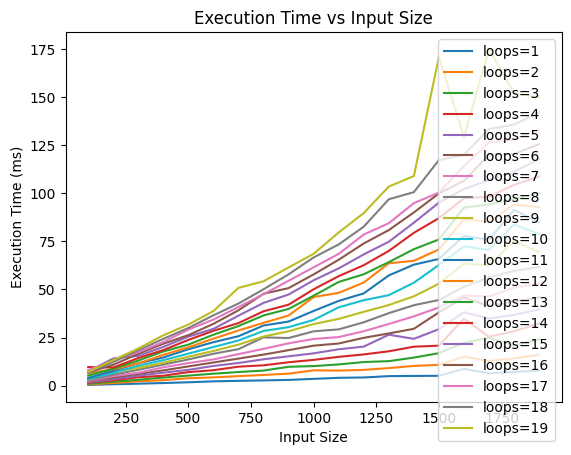

In [25]:
for loops in df["loop_iterations"].unique():
    subset = df[df["loop_iterations"] == loops]
    plt.plot(subset["input_size"], subset["execution_time"], label=f"loops={loops}")

plt.xlabel("Input Size");
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.title("Execution Time vs Input Size")
plt.show();

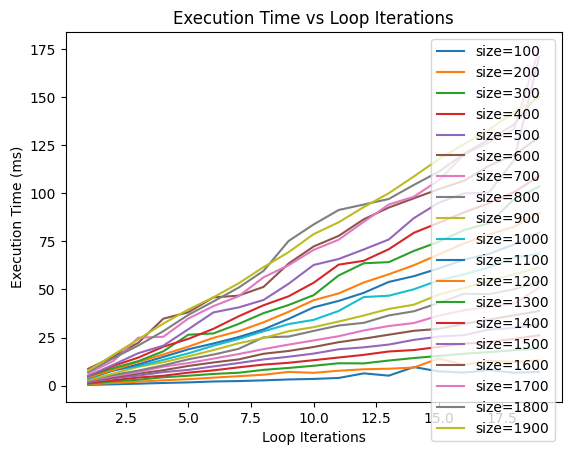

In [26]:
for size in df["input_size"].unique():
    subset = df[df["input_size"] == size]
    plt.plot(subset["loop_iterations"], subset["execution_time"], label = f"size={size}")

plt.xlabel("Loop Iterations")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.title("Execution Time vs Loop Iterations")
plt.show()

In [27]:
df["interaction"] = df["input_size"] * df["loop_iterations"]

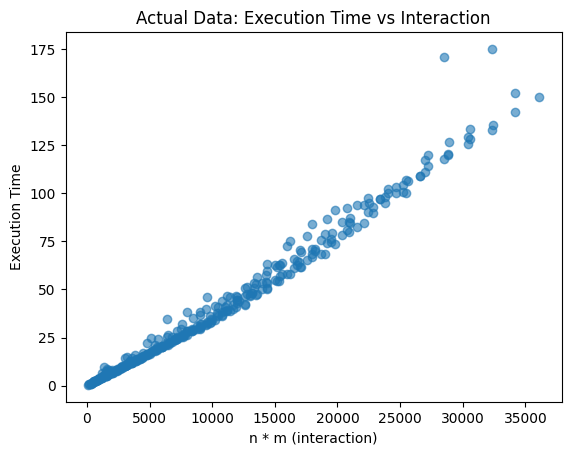

In [34]:
# Plot 1: Actual data vs interaction

plt.scatter(df["interaction"], df["execution_time"], alpha=0.6)
plt.xlabel("n * m (interaction)")
plt.ylabel("Execution Time")
plt.title("Actual Data: Execution Time vs Interaction")
plt.show()

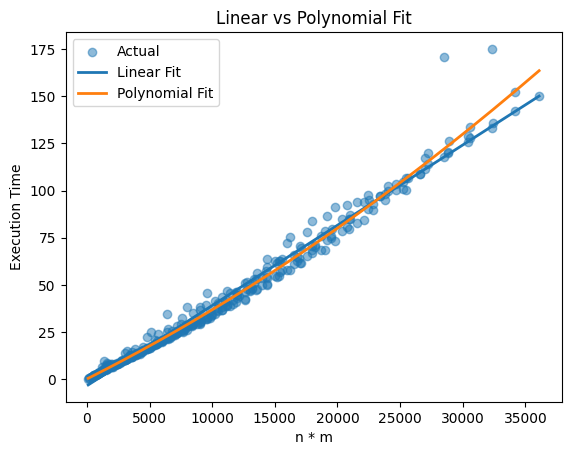

In [29]:
# Plot 2: Model comparison (fit curves)

# Sort for smooth plotting
sorted_idx = np.argsort(df["interaction"])
interaction_sorted = df["interaction"].values[sorted_idx]
y_sorted = df["execution_time"].values[sorted_idx]

# Linear model prediction (only interaction)
X_linear = np.vstack((np.ones_like(interaction_sorted), interaction_sorted)).T
y_linear = X_linear @ np.linalg.pinv(X_linear) @ y_sorted

# Polynomial model prediction
interaction_sq = interaction_sorted**2
X_poly = np.vstack((np.ones_like(interaction_sorted), interaction_sorted, interaction_sq)).T
y_poly = X_poly @ np.linalg.pinv(X_poly) @ y_sorted

# Plot
plt.scatter(interaction_sorted, y_sorted, label="Actual", alpha=0.5)
plt.plot(interaction_sorted, y_linear, label="Linear Fit", linewidth=2)
plt.plot(interaction_sorted, y_poly, label="Polynomial Fit", linewidth=2)

plt.xlabel("n * m")
plt.ylabel("Execution Time")
plt.title("Linear vs Polynomial Fit")
plt.legend()
plt.show()

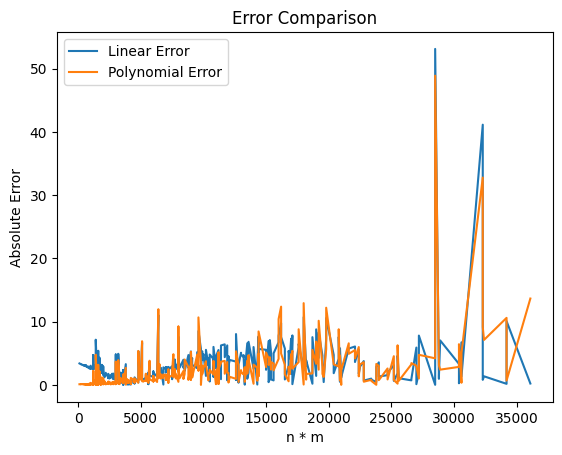

In [30]:
# Plot 3: Error comparison

error_linear = abs(y_sorted - y_linear)
error_poly = abs(y_sorted - y_poly)

plt.plot(interaction_sorted, error_linear, label="Linear Error")
plt.plot(interaction_sorted, error_poly, label="Polynomial Error")

plt.xlabel("n * m")
plt.ylabel("Absolute Error")
plt.title("Error Comparison")
plt.legend()
plt.show()

Without Interaction:

In [31]:
# Model 1: Polynomial WITHOUT interaction

# Features
X1 = df[["input_size", "loop_iterations"]].values
y = df["execution_time"].values

# Polynomial terms
input_sq = (df["input_size"] ** 2).values.reshape(-1, 1)
loop_sq = (df["loop_iterations"] ** 2).values.reshape(-1, 1)

# Combine features
X1 = np.hstack((X1, input_sq, loop_sq))

# Add bias
X1 = np.hstack((np.ones((X1.shape[0], 1)), X1))

# Train
w1 = np.linalg.pinv(X1) @ y       # Normal Equation using pseudo-inverse

# Prediction on training (for MSE)
y_pred1 = X1 @ w1
mse1 = np.mean((y - y_pred1) ** 2)

print("MSE (Polynomial WITHOUT interaction):", mse1)

MSE (Polynomial WITHOUT interaction): 203.69958908142897


With Interaction

In [32]:
# Model 2: Polynomial WITH interaction

# Feature engineering
df["interaction"] = df["input_size"] * df["loop_iterations"]
df["interaction_sq"] = df["interaction"] ** 2

# Features
X2 = df[["interaction", "interaction_sq"]].values
y = df["execution_time"].values

# Add bias
X2 = np.hstack((np.ones((X2.shape[0], 1)), X2))

# Train
w2 = np.linalg.pinv(X2) @ y

# Prediction on training (for MSE)
y_pred2 = X2 @ w2
mse2 = np.mean((y - y_pred2) ** 2)

print("MSE (Polynomial WITH interaction):", mse2)

MSE (Polynomial WITH interaction): 19.610066868795005


Testing and Prediction

In [ ]:
# Prediction

n = int(input("Enter input_size: "))
m = int(input("Enter loop_iterations: "))

# Restrict range
if n < 100 or n > 1900 or m < 1 or m > 19:
    print("Input out of range!")
else:
    print(f"\nUsing input_size: {n}, loop_iterations: {m}")

    # Model 1 Prediction (no interaction)
    X_new1 = np.array([
        1,
        n,
        m,
        n**2,
        m**2
    ])
    pred1 = X_new1 @ w1

    # Model 2 Prediction (with interaction)
    interaction = n * m
    X_new2 = np.array([
        1,
        interaction,
        interaction**2
    ])
    pred2 = X_new2 @ w2

    # Dataset Comparison (snap only here)
    n_data = round(n / 100) * 100
    m_data = int(round(m))

    print(f"\nNearest dataset point to input_size: {n_data}, loop_iterations: {m_data}")

    # Actual value
    row = df[
        (df["input_size"] == n_data) &
        (df["loop_iterations"] == m_data)
    ]

    if not row.empty:
        actual = row["execution_time"].values[0]

        print("\nActual:", actual)

        print("\n--- Model Comparison ---")
        print("Polynomial WITHOUT interaction:", pred1)
        print("Polynomial WITH interaction:", pred2)

        print("\nError (No Interaction):", abs(actual - pred1))
        print("Error (With Interaction):", abs(actual - pred2))
    else:
        print("No matching data found.")


Using nearest values to input_size: 100, loop_iterations: 3

Actual: 1.0027400683611631

--- Model Comparison ---
Polynomial WITHOUT interaction: -23.884108960837004
Polynomial WITH interaction: 1.1481297806541757

Error (No Interaction): 24.886849029198167
Error (With Interaction): 0.14538971229301256
